In [73]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [74]:
data=pd.read_csv(r"C:\Users\Dell\python class\capstone,csv")

In [75]:
data.drop(["name","vehicle_uid"],axis=1,inplace=True)

# 1. Data Loading and Problem Identification

• Load the cleaned Car Evaluation dataset   
• Identify the type of Machine Learning problem   
• Select price_category as the target variable      
• Print the shape of X (features) and y (target)   

In [76]:
x=data.drop("price_category",axis=1)
y=data["price_category"]

In [77]:
print(x.shape)
print(y.shape)

(4340, 15)
(4340,)


# 2. Data Preprocessing

• Identify categorical columns   
• Apply encoding techniques (if required)     
• Perform standard scaling on numerical features       

In [78]:
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [79]:
scale=StandardScaler()
label=LabelEncoder()

In [80]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   year               4340 non-null   int64  
 1   selling_price      4340 non-null   float64
 2   km_driven          4340 non-null   float64
 3   fuel               4340 non-null   object 
 4   seller_type        4340 non-null   object 
 5   transmission       4340 non-null   object 
 6   owner              4340 non-null   object 
 7   car_record_id      4340 non-null   int64  
 8   car_age            4340 non-null   int64  
 9   price_category     4340 non-null   object 
 10  km_category        4340 non-null   object 
 11  owner_count        4340 non-null   float64
 12  fuel_transmission  4340 non-null   object 
 13  brand              4340 non-null   object 
 14  price_per_km       4340 non-null   float64
 15  is_diesel          4340 non-null   int64  
dtypes: float64(4), int64(4),

In [81]:
data.columns

Index(['year', 'selling_price', 'km_driven', 'fuel', 'seller_type',
       'transmission', 'owner', 'car_record_id', 'car_age', 'price_category',
       'km_category', 'owner_count', 'fuel_transmission', 'brand',
       'price_per_km', 'is_diesel'],
      dtype='object')

In [82]:
columns=["fuel","seller_type","transmission","owner","price_category","km_category","fuel_transmission","brand"]

In [83]:
for i in columns:
    data[i]=label.fit_transform(data[i])

In [84]:
data

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,car_record_id,car_age,price_category,km_category,owner_count,fuel_transmission,brand,price_per_km,is_diesel
0,2007,60000.0,60000.0,4,1,1,0,1,18,1,2,0.0,6,18,0.86,0
1,2007,135000.0,60000.0,4,1,1,0,2,18,1,2,0.0,6,18,2.70,0
2,2012,600000.0,60000.0,1,1,1,0,3,13,1,2,0.0,2,10,6.00,1
3,2017,250000.0,60000.0,4,1,1,0,4,8,1,2,0.0,6,5,5.43,0
4,2014,450000.0,60000.0,1,1,1,2,5,11,1,0,0.0,2,9,3.19,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4335,2014,409999.0,60000.0,1,1,1,2,4336,11,2,0,0.0,2,10,5.12,1
4336,2014,409999.0,60000.0,1,1,2,2,4337,11,2,0,0.0,2,10,5.12,1
4337,2009,110000.0,60000.0,4,1,1,2,4338,16,1,0,0.0,6,18,1.33,0
4338,2016,865000.0,60000.0,1,1,1,0,4339,9,0,0,0.0,2,10,9.61,1


In [85]:
x=data.drop("price_category",axis=1)
y=data["price_category"]

In [86]:
x=scale.fit_transform(x)

# 3. Data Visualization and Analysis

• Plot the distribution of car price categories     
• Analyse the relationship between:     
Safety    
Selling price indicators  
Number of owners      
km driven     
• Compare these features with the target variable price_category      

In [87]:
import seaborn as sns 

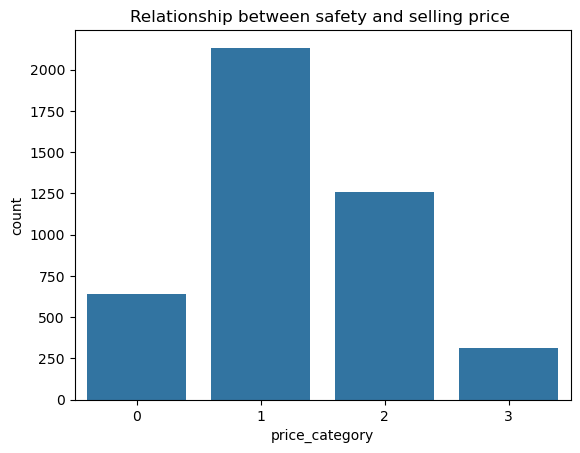

In [88]:
sns.countplot(x="price_category",data=data)
plt.title("Relationship between safety and selling price ")
plt.show()

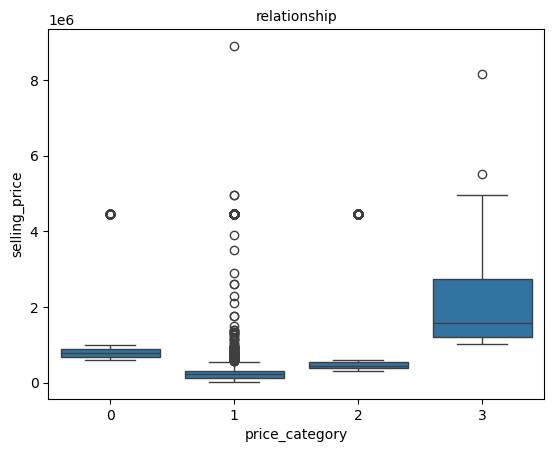

In [89]:
sns.boxplot(x="price_category",y="selling_price",data=data)
plt.title("relationship",fontsize=10)
plt.show()

# 4. Model Training – Support Vector Machine (SVM)

• Split the dataset into training and testing sets     
• Train the SVM model   
• Evaluate using:      
Accuracy Score    
Confusion Matrix    
Classification Report  

In [90]:
x=data.drop("price_category",axis=1)
y=data["price_category"]

In [91]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

In [92]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=47)

In [93]:
from sklearn.svm import SVC

In [94]:
model=SVC(C=45,kernel="rbf")

In [95]:
model.fit(x_train,y_train)

SVC(C=45)

In [96]:
model.score(x_train,y_train)

0.8778801843317973

In [97]:
model.score(x_test,y_test)

0.8536866359447005

In [98]:
ypri=model.predict(x_test)
ypri

array([1, 2, 1, 0, 1, 3, 1, 2, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 2, 1, 1, 1,
       1, 1, 3, 1, 0, 1, 1, 1, 1, 1, 3, 2, 2, 2, 1, 2, 2, 1, 0, 2, 3, 1,
       2, 2, 3, 3, 0, 1, 1, 2, 1, 0, 1, 0, 0, 1, 1, 3, 2, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 0, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 3, 1, 2, 0, 2, 2, 1,
       0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 2, 2, 3, 1, 1, 1, 1, 0,
       1, 1, 1, 3, 2, 2, 0, 2, 2, 3, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 2, 1, 2,
       2, 1, 0, 0, 2, 0, 2, 3, 1, 3, 2, 1, 0, 1, 2, 3, 1, 1, 1, 1, 1, 2,
       1, 2, 2, 2, 1, 2, 2, 3, 2, 1, 1, 0, 2, 2, 2, 1, 1, 2, 1, 2, 2, 0,
       3, 0, 1, 1, 2, 1, 2, 1, 1, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 0, 2,
       1, 0, 0, 1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 0,
       2, 1, 1, 2, 1, 1, 1, 2, 1, 0, 2, 3, 2, 2, 0, 0, 2, 2, 1, 0, 2, 0,
       1, 3, 3, 1, 0, 1, 2, 1, 1, 1, 1, 1, 3, 1, 0,

In [99]:
acc_sv=accuracy_score(y_test,ypri)
acc_sv

0.8536866359447005

In [100]:
a=confusion_matrix(y_test,ypri)
a

array([[ 99,  13,  10,   0],
       [ 18, 387,  25,   8],
       [  0,  43, 209,   0],
       [  1,   9,   0,  46]])

# 5. Model Training – Random Forest Classifier
• Train Random Forest model on same dataset            
• Predict price_category        
• Evaluate using:            
Accuracy Score      
Confusion Matrix         
Classification Report          
• Compare both models      
• Select and print the best model for prediction  

In [101]:
from sklearn.ensemble import RandomForestClassifier

In [102]:
model3=RandomForestClassifier()

In [103]:
model.fit(x_train,y_train)

SVC(C=45)

In [104]:
ypri1=model.predict(x_test)
ypri

array([1, 2, 1, 0, 1, 3, 1, 2, 2, 2, 1, 1, 0, 1, 1, 1, 2, 1, 2, 1, 1, 1,
       1, 1, 3, 1, 0, 1, 1, 1, 1, 1, 3, 2, 2, 2, 1, 2, 2, 1, 0, 2, 3, 1,
       2, 2, 3, 3, 0, 1, 1, 2, 1, 0, 1, 0, 0, 1, 1, 3, 2, 1, 1, 2, 2, 1,
       2, 1, 2, 1, 0, 1, 3, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 2, 1,
       1, 1, 2, 2, 2, 1, 2, 1, 1, 1, 1, 1, 2, 1, 2, 3, 1, 2, 0, 2, 2, 1,
       0, 2, 2, 1, 1, 1, 1, 1, 1, 1, 1, 2, 0, 2, 2, 2, 3, 1, 1, 1, 1, 0,
       1, 1, 1, 3, 2, 2, 0, 2, 2, 3, 2, 1, 2, 1, 2, 1, 1, 1, 2, 1, 1, 1,
       1, 1, 1, 2, 1, 1, 2, 1, 2, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 2, 1, 2,
       2, 1, 0, 0, 2, 0, 2, 3, 1, 3, 2, 1, 0, 1, 2, 3, 1, 1, 1, 1, 1, 2,
       1, 2, 2, 2, 1, 2, 2, 3, 2, 1, 1, 0, 2, 2, 2, 1, 1, 2, 1, 2, 2, 0,
       3, 0, 1, 1, 2, 1, 2, 1, 1, 1, 2, 0, 2, 1, 2, 2, 0, 1, 1, 1, 0, 2,
       1, 0, 0, 1, 1, 0, 2, 0, 1, 1, 1, 1, 1, 1, 2, 2, 1, 2, 1, 1, 1, 0,
       2, 1, 1, 2, 1, 1, 1, 2, 1, 0, 2, 3, 2, 2, 0, 0, 2, 2, 1, 0, 2, 0,
       1, 3, 3, 1, 0, 1, 2, 1, 1, 1, 1, 1, 3, 1, 0,

In [105]:
acc_rf=accuracy_score(y_test,ypri1)
acc_rf

0.8536866359447005

In [106]:
confusion_matrix(y_test,ypri)

array([[ 99,  13,  10,   0],
       [ 18, 387,  25,   8],
       [  0,  43, 209,   0],
       [  1,   9,   0,  46]])

In [107]:
print(classification_report(y_test,ypri))

              precision    recall  f1-score   support

           0       0.84      0.81      0.82       122
           1       0.86      0.88      0.87       438
           2       0.86      0.83      0.84       252
           3       0.85      0.82      0.84        56

    accuracy                           0.85       868
   macro avg       0.85      0.84      0.84       868
weighted avg       0.85      0.85      0.85       868



In [108]:
if acc_sv > acc_rf:
    print("Random Forest is Best Model")
else:
    print("SVM is Best Model")
print(acc_sv)
print(acc_rf)

SVM is Best Model
0.8536866359447005
0.8536866359447005
